# ForestClustering on synthetic mixed-type data

This notebook is both a tutorial and a controlled benchmark. Because the generator supplies true labels, ARI is meaningful here; because the data were designed by us, the result is evidence only for this particular family of problems.

We will:

1. create five known clusters with numeric, binary, categorical, correlated, and noise features;
2. inspect the learned embedding and correlation weights;
3. compare ForestClustering with ordinary sklearn baselines in a common evaluation space;
4. show where graph community detection helps and where it over-segments;
5. run a contamination experiment on the **same core observations**; and
6. demonstrate incremental fitting and empirical runtime scaling.

Timings are illustrative machine-dependent measurements, not a universal speed ranking.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import (KMeans, MiniBatchKMeans, DBSCAN,
                             AgglomerativeClustering)
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import connected_components
import time
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), ''))
from forest_clustering import ForestClusterer, GraphLouvainClusterer
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})
PALETTE5 = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
ALGO_COLOR = {
    'ForestClusterer': '#2196F3',
    'KMeans': '#FF9800',
    'MiniBatchKMeans': '#FFC107',
    'AgglomerativeClustering': '#4CAF50',
    'DBSCAN': '#9C27B0',
}


## 1. Data generator

The benchmark contains:

- three informative continuous features;
- two informative binary features;
- two informative categorical features;
- two near-copies of continuous features, included to exercise correlation-aware weighting; and
- three independent noise features.

The construction deliberately favours methods that can exploit compact, roughly separated groups. We therefore include strong KMeans and agglomerative baselines rather than treating mixed-type convenience as proof of superior clustering.

In [2]:
def make_mixed_dataset(n_samples: int, n_clusters: int = 5,
                       outlier_fraction: float = 0.0, seed: int = 42):
    """Generate mixed-type clustering benchmark dataset.
    Returns (df, true_labels). true_labels == -1 marks outliers.
    Feature layout:
    cont_1/2/3 — informative continuous
    binary_1/2 — informative binary
    cat_1 (A-D) — informative categorical, 4 categories
    cat_2 (v-z) — informative categorical, 5 categories
    corr_1/2 — strongly correlated with cont_1/2 (triggers 1/G weighting)
    noise_1/2/3 — pure noise
    """
    rng = np.random.default_rng(seed)
    n_out = int(n_samples * outlier_fraction)
    n_core = n_samples - n_out
    sizes = np.full(n_clusters, n_core // n_clusters, dtype=int)
    sizes[:n_core % n_clusters] += 1
    centers = rng.uniform(-7, 7, (n_clusters, 3))
    for _ in range(200):
        ok = True
        for i in range(n_clusters):
            for j in range(i+1, n_clusters):
                if np.linalg.norm(centers[i]-centers[j]) < 4:
                    centers[j] = rng.uniform(-7, 7, 3)
                    ok = False
        if ok:
            break
    cont_parts, bin_parts, cat_parts, labels = [], [], [], []
    for k, n_k in enumerate(sizes):
        labels.extend([k] * n_k)
        cont_parts.append(rng.normal(centers[k], 0.9, (n_k, 3)))
        p1 = 0.1 + 0.8 * k / (n_clusters - 1)
        p2 = 0.9 - 0.8 * k / (n_clusters - 1)
        bin_parts.append(rng.binomial(1, [p1, p2], (n_k, 2)).astype(float))
        d1 = np.full(4, 0.1/3)
        d1[k % 4] = 0.7
        d1 /= d1.sum()
        d2 = np.full(5, 0.1/4)
        d2[k % 5] = 0.6
        d2 /= d2.sum()
        cat_parts.append(np.column_stack([rng.choice(4, n_k, p=d1),
                                          rng.choice(5, n_k, p=d2)]))
    X_cont = np.vstack(cont_parts)
    X_bin = np.vstack(bin_parts)
    X_cat = np.vstack(cat_parts)
    X_corr = X_cont[:, :2] + rng.normal(0, 0.08, (n_core, 2))
    X_noise = rng.normal(0, 4, (n_core, 3))
    y_core = np.array(labels)
    if n_out > 0:
        X_out_cont = rng.uniform(-22, 22, (n_out, 3))
        X_out_bin = rng.binomial(1, 0.5, (n_out, 2)).astype(float)
        X_out_cat = np.column_stack([rng.integers(0, 4, n_out),
                                     rng.integers(0, 5, n_out)])
        X_out_corr = rng.uniform(-22, 22, (n_out, 2))
        X_out_noise = rng.normal(0, 4, (n_out, 3))
        X_cont = np.vstack([X_cont, X_out_cont])
        X_bin = np.vstack([X_bin, X_out_bin])
        X_cat = np.vstack([X_cat, X_out_cat])
        X_corr = np.vstack([X_corr, X_out_corr])
        X_noise = np.vstack([X_noise, X_out_noise])
        y_core = np.concatenate([y_core, np.full(n_out, -1)])
    else:
        y_all = y_core
    X_all = np.hstack([X_cont, X_bin, X_cat.astype(float), X_corr, X_noise])
    perm = rng.permutation(n_samples)
    X_all, y_all = X_all[perm], y_core[perm]
    COL_NAMES = ['cont_1','cont_2','cont_3',
                 'binary_1','binary_2',
                 'cat_1','cat_2',
                 'corr_1','corr_2',
                 'noise_1','noise_2','noise_3']
    df = pd.DataFrame(X_all, columns=COL_NAMES)
    df['cat_1'] = df['cat_1'].astype(int).map({0:'A',1:'B',2:'C',3:'D'})
    df['cat_2'] = df['cat_2'].astype(int).map({0:'v',1:'w',2:'x',3:'y',4:'z'})
    df['binary_1'] = df['binary_1'].astype(int)
    df['binary_2'] = df['binary_2'].astype(int)
    return df, y_all

def append_uniform_outliers(df_core, y_core, fraction=0.10, seed=2024):
    """Append outliers while preserving every original observation and label."""
    rng = np.random.default_rng(seed)
    n_out = int(round(len(df_core) * fraction))
    outliers = pd.DataFrame({
        'cont_1': rng.uniform(-22, 22, n_out),
        'cont_2': rng.uniform(-22, 22, n_out),
        'cont_3': rng.uniform(-22, 22, n_out),
        'binary_1': rng.integers(0, 2, n_out),
        'binary_2': rng.integers(0, 2, n_out),
        'cat_1': rng.choice(list('ABCD'), n_out),
        'cat_2': rng.choice(list('vwxyz'), n_out),
        'corr_1': rng.uniform(-22, 22, n_out),
        'corr_2': rng.uniform(-22, 22, n_out),
        'noise_1': rng.normal(0, 4, n_out),
        'noise_2': rng.normal(0, 4, n_out),
        'noise_3': rng.normal(0, 4, n_out),
    })
    df_dirty = pd.concat([df_core, outliers], ignore_index=True)
    y_dirty = np.concatenate([y_core, np.full(n_out, -1, dtype=int)])
    return df_dirty, y_dirty
N_COMPARE = 10_000
N_CLUSTERS = 5
df_clean, y_clean = make_mixed_dataset(N_COMPARE, n_clusters=N_CLUSTERS, seed=42)
df_dirty, y_dirty = append_uniform_outliers(df_clean, y_clean, fraction=0.10)
print(f"Clean dataset: {df_clean.shape}, clusters: {sorted(set(y_clean))}")
print(f"Polluted dataset: {df_dirty.shape}, outliers: {(y_dirty==-1).sum()}")
df_clean.head()


Clean dataset: (10000, 12), clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Polluted dataset: (11000, 12), outliers: 1000


,cont_1,cont_2,cont_3,binary_1,binary_2,cat_1,cat_2,corr_1,corr_2,noise_1,noise_2,noise_3
0,3.969920,0.227702,5.546996,0,1,A,v,4.038986,0.273261,1.344649,-5.116878,-1.493421
1,2.616992,-6.356116,6.483097,0,1,B,w,2.482916,-6.218959,-5.830491,-0.879083,-7.504218
2,4.132028,-5.896310,7.134604,0,1,B,w,4.178489,-5.925930,2.006446,-0.123427,0.814626
3,1.771551,-5.670996,7.421780,1,0,B,w,1.717313,-5.834365,-1.968188,5.476234,-9.433975
4,1.006285,5.139441,-0.836930,1,0,A,w,0.937357,5.174312,-1.295639,-1.680213,1.243033


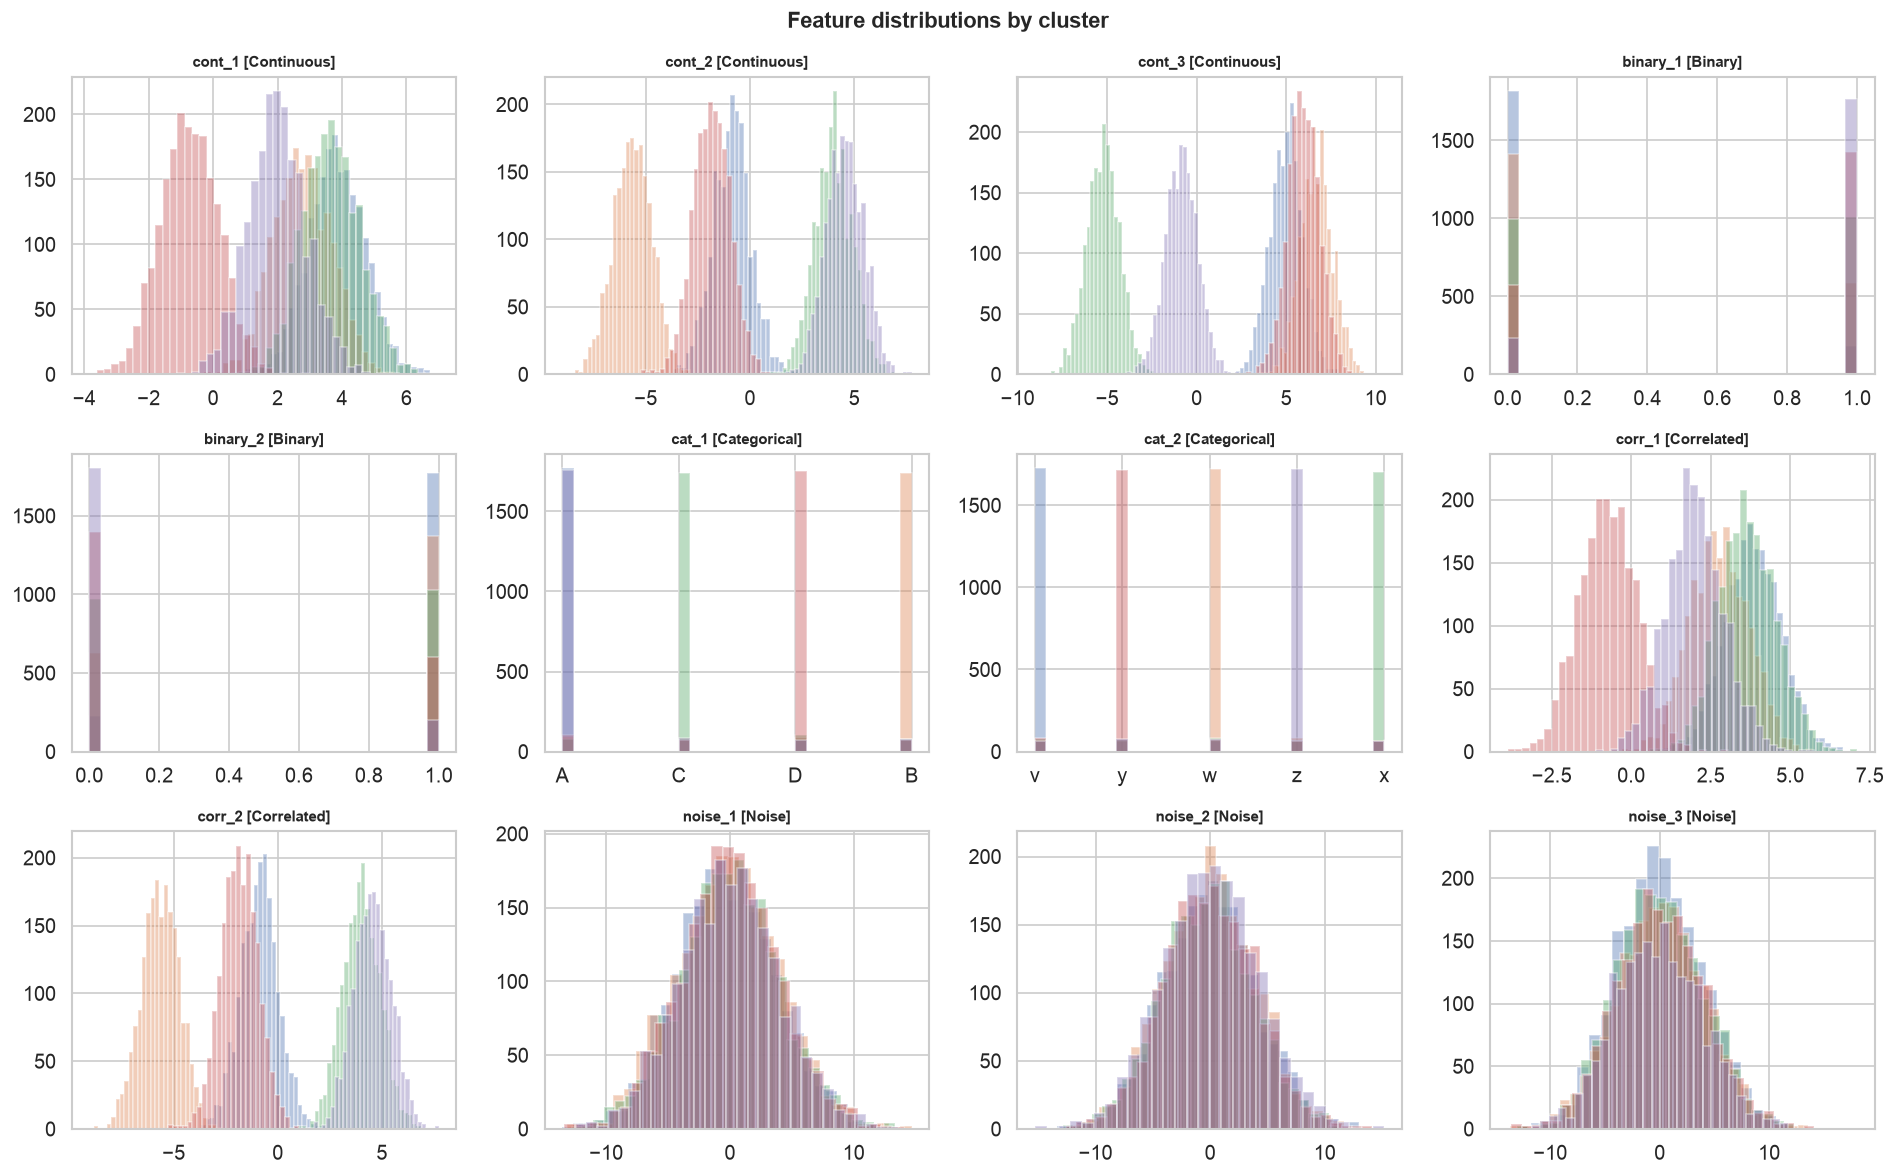

In [3]:
# EDA: feature types and distributions
COL_NAMES = df_clean.columns.tolist()
FEATURE_GROUPS = {
    'Continuous': ['cont_1', 'cont_2', 'cont_3'],
    'Binary': ['binary_1', 'binary_2'],
    'Categorical': ['cat_1', 'cat_2'],
    'Correlated': ['corr_1', 'corr_2'],
    'Noise': ['noise_1', 'noise_2', 'noise_3'],
}
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()
ax_idx = 0
for group, cols in FEATURE_GROUPS.items():
    for col in cols:
        ax = axes[ax_idx]
        if df_clean[col].dtype == object:
            df_clean[col].value_counts().sort_index().plot.bar(ax=ax, color='#4C72B0',
                                                               edgecolor='white')
            ax.tick_params(axis='x', rotation=0)
        else:
            for k in range(N_CLUSTERS):
                mask = y_clean == k
                ax.hist(df_clean.loc[mask, col], bins=30, alpha=0.4,
                        color=PALETTE5[k], label=f'cl {k+1}')
        ax.set_title(f'{col} [{group}]', fontsize=9, fontweight='bold')
        ax.set_ylabel('')
        ax_idx += 1
for i in range(ax_idx, len(axes)):
    axes[i].set_visible(False)
plt.suptitle('Feature distributions by cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


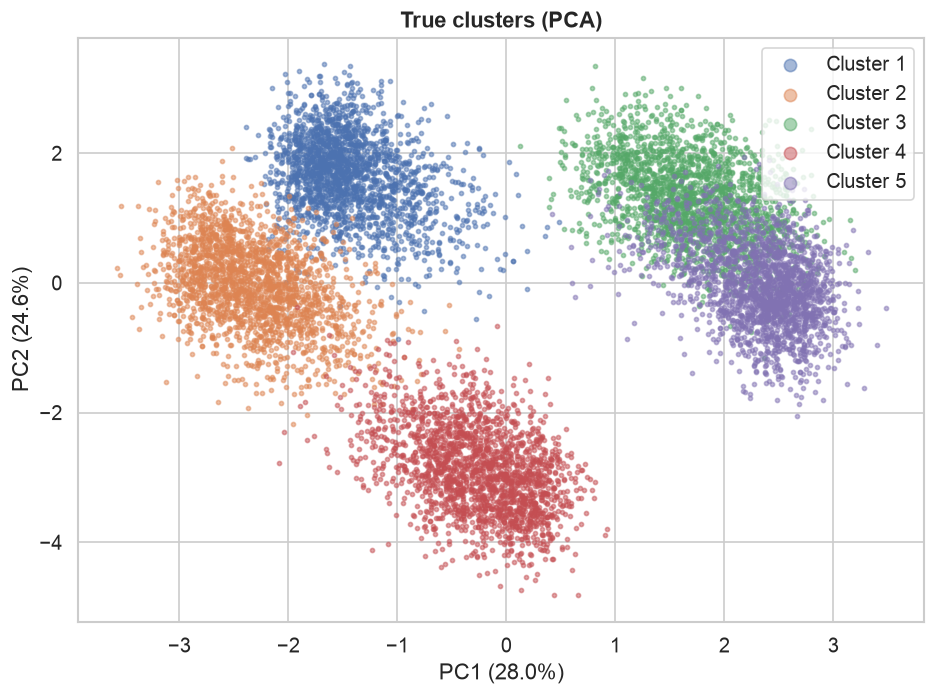

In [4]:
# PCA: true clusters
from sklearn.preprocessing import OrdinalEncoder as OE
X_vis = df_clean.copy()
X_vis['cat_1'] = OE().fit_transform(X_vis[['cat_1']])
X_vis['cat_2'] = OE().fit_transform(X_vis[['cat_2']])
X_scaled = StandardScaler().fit_transform(X_vis.astype(float))
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8, 6))
for k in range(N_CLUSTERS):
    m = y_clean == k
    ax.scatter(coords[m, 0], coords[m, 1], s=6, alpha=0.5, color=PALETTE5[k], label=f'Cluster {k+1}')
ax.set_title('True clusters (PCA)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(markerscale=3, loc='upper right')
plt.tight_layout()
plt.show()


## 2. ForestClusterer: embedding and feature weights

Because the generator defines five classes, we pass `n_clusters=5`; this invokes the library's default KMeans backend on weighted one-hot cell indicators. The integer cell ids themselves are nominal and are not treated as Euclidean coordinates.

The feature-weight plot is diagnostic. Correlated groups receive a shared `1/G` weight so duplicate columns do not automatically multiply their influence. Correctly detecting a duplicate is not the same as proving a quality improvement, so the later baseline table remains decisive.

In [5]:
t0 = time.perf_counter()
fc = ForestClusterer(
    n_iterations=250,
    n_bins=3,
    quantile_cuts=True,
    n_clusters=N_CLUSTERS,      # default KMeans internally
    corr_threshold=0.9,
    corr_sample_size=5_000,
    random_state=42,
)
fc_labels = fc.fit_predict(df_clean)
fc_time = time.perf_counter() - t0
ari = adjusted_rand_score(y_clean, fc_labels)
sil = silhouette_score(fc.get_embedding().astype(float), fc_labels,
                       metric='hamming', sample_size=2000, random_state=0)
print(f"ForestClusterer | ARI={ari:.3f} Silhouette={sil:.3f} Time={fc_time:.1f}s")


ForestClusterer | ARI=0.925 Silhouette=0.166 Time=2.3s


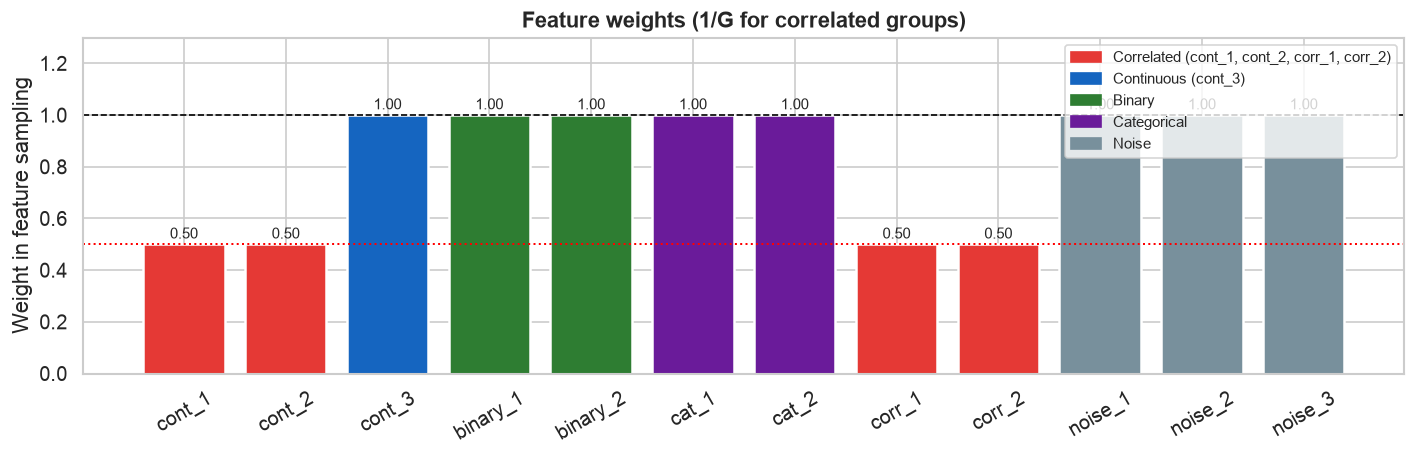

Correlated features detected: ['cont_1', 'cont_2', 'corr_1', 'corr_2']


In [6]:
# Feature weights
weights = fc.feature_weights_
features = COL_NAMES
GROUP_COLOR = {
    'cont_1': '#E53935', 'cont_2': '#E53935', 'cont_3': '#1565C0',
    'binary_1': '#2E7D32', 'binary_2': '#2E7D32',
    'cat_1': '#6A1B9A', 'cat_2': '#6A1B9A',
    'corr_1': '#E53935', 'corr_2': '#E53935',
    'noise_1': '#78909C', 'noise_2': '#78909C', 'noise_3': '#78909C',
}
fig, ax = plt.subplots(figsize=(12, 4))
colors = [GROUP_COLOR.get(f, '#78909C') for f in features]
bars = ax.bar(features, weights, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(1.0, color='black', ls='--', lw=1, label='weight=1 (independent)')
ax.axhline(0.5, color='red', ls=':', lw=1.2, label='weight=0.5 (group of 2)')
legend_patches = [
    Patch(color='#E53935', label='Correlated (cont_1, cont_2, corr_1, corr_2)'),
    Patch(color='#1565C0', label='Continuous (cont_3)'),
    Patch(color='#2E7D32', label='Binary'),
    Patch(color='#6A1B9A', label='Categorical'),
    Patch(color='#78909C', label='Noise'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)
for bar, w in zip(bars, weights):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{w:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 1.3)
ax.set_title('Feature weights (1/G for correlated groups)', fontweight='bold', fontsize=13)
ax.set_ylabel('Weight in feature sampling')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
print("Correlated features detected:", [f for f,w in zip(features,weights) if w < 0.99])


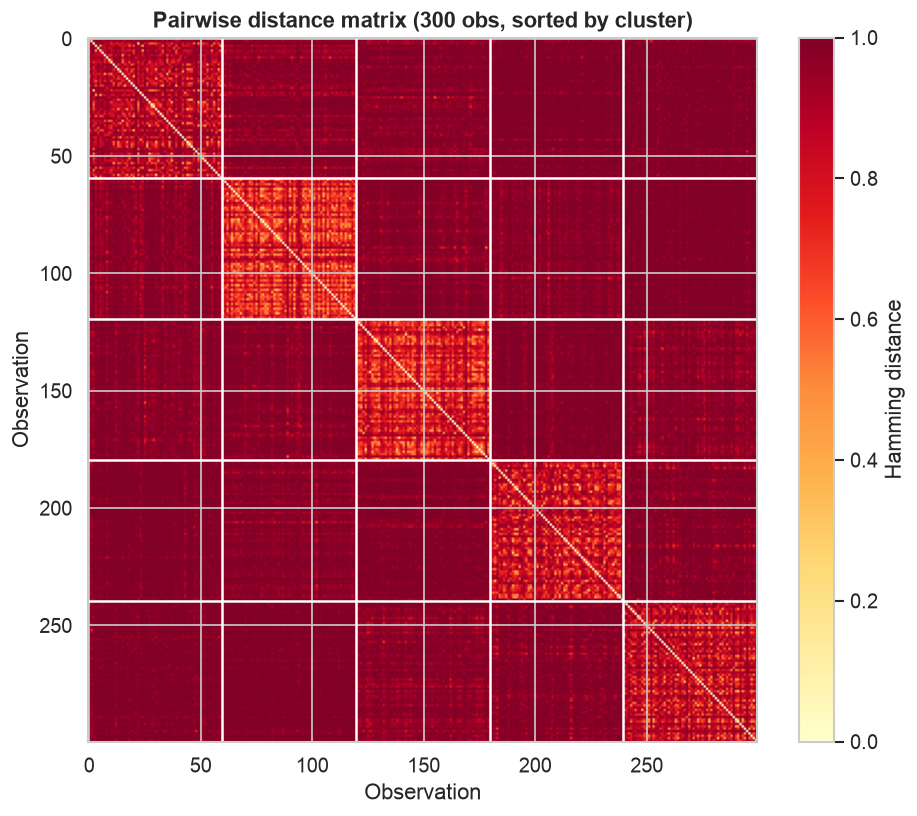

In [7]:
# Distance matrix visualisation (subsample 300 obs, sorted by cluster)
SAMPLE_VIZ = 300
sample_idx = []
for k in range(N_CLUSTERS):
    idxs = np.where(fc_labels == k)[0]
    sample_idx.extend(np.random.choice(idxs, min(SAMPLE_VIZ // N_CLUSTERS, len(idxs)), replace=False))
sample_idx = np.array(sample_idx)
E_sub = fc.get_embedding()[sample_idx]
from forest_clustering import pairwise_hamming
D_sub = pairwise_hamming(E_sub)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(D_sub, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Hamming distance')
n_per_cluster = len(sample_idx) // N_CLUSTERS
for i in range(1, N_CLUSTERS):
    ax.axhline(i * n_per_cluster - 0.5, color='white', lw=1.5)
    ax.axvline(i * n_per_cluster - 0.5, color='white', lw=1.5)
ax.set_title('Pairwise distance matrix (300 obs, sorted by cluster)', fontweight='bold')
ax.set_xlabel('Observation')
ax.set_ylabel('Observation')
plt.tight_layout()
plt.show()


## 3. Graph clustering: Louvain and Leiden

Community detection does not require a target number of clusters, but it is **not parameter-free**: `n_neighbors`, `resolution`, and graph construction determine the result. Here we use an explicitly sparse LSH-banded kNN graph. LSH reduces memory and candidate-search cost, but it is approximate and can disconnect observations that have no candidate neighbours.

The settings below (`k=100`, `resolution=0.1`) intentionally smooth more than the defaults. They are illustrative settings selected after exploratory work, not a held-out optimum. On these five roughly Gaussian groups, both community methods still over-segment and underperform fixed-`K` baselines. That is a useful boundary of the tool, not a result to hide.

In [8]:
# Learn one embedding and reuse it so both graph methods see the same representation.
t0 = time.perf_counter()
fc_graph_embedding = ForestClusterer(
    n_iterations=250, n_bins=3, quantile_cuts=True,
    corr_threshold=0.9, corr_sample_size=5_000, random_state=42,
)
E_graph = fc_graph_embedding.fit_transform(df_clean)
graph_embedding_time = time.perf_counter() - t0

graph_louvain = GraphLouvainClusterer(
    n_neighbors=100, resolution=0.1,
    community_method='louvain', random_state=42,
)
t0 = time.perf_counter()
graph_louvain.fit_embedding(
    E_graph, method='banding', band_size='auto', max_bucket=150
)
louvain_graph_time = time.perf_counter() - t0
lbl_louvain = graph_louvain.labels_


In [9]:
# Leiden is optional; the notebook remains executable without the extra dependency.
lbl_leiden = None
leiden_graph_time = None
try:
    graph_leiden = GraphLouvainClusterer(
        n_neighbors=100, resolution=0.1,
        community_method='leiden', random_state=42,
    )
    t0 = time.perf_counter()
    graph_leiden.fit_embedding(
        E_graph, method='banding', band_size='auto', max_bucket=150
    )
    leiden_graph_time = time.perf_counter() - t0
    lbl_leiden = graph_leiden.labels_
except ImportError as exc:
    print(f'Leiden skipped: {exc}')


In [10]:
graph_rows = []
for name, labels, graph_time in [
    ('Louvain', lbl_louvain, louvain_graph_time),
    ('Leiden', lbl_leiden, leiden_graph_time),
]:
    if labels is None:
        continue
    mask = labels >= 0
    graph_rows.append({
        'Method': name,
        'Clusters': len(set(labels[mask])),
        'Noise %': f'{(~mask).mean():.1%}',
        'ARI': round(adjusted_rand_score(y_clean, labels), 3),
        'End-to-end time, s': round(graph_embedding_time + graph_time, 2),
    })
graph_results = pd.DataFrame(graph_rows).set_index('Method')
graph_results


,Clusters,Noise %,ARI,"End-to-end time, s"
Method,,,,
Louvain,6,0.0%,0.895,23.83
Leiden,6,0.0%,0.896,20.42


In [11]:
# Connectivity explains why an approximate graph may fragment.
G_lsh = graph_louvain.knn_graph_.maximum(graph_louvain.knn_graph_.T)
n_components, component_labels = connected_components(G_lsh, directed=False)
component_sizes = np.bincount(component_labels)
print(f'LSH graph: {G_lsh.nnz // 2:,} undirected edges')
print(f'Connected components: {n_components:,}')
print(f'Isolated vertices: {(component_sizes == 1).sum():,}')
print(f'Largest component: {component_sizes.max():,} observations')
print('A disconnected graph imposes a lower bound on the number of communities;')
print('always inspect connectivity before interpreting the community count.')


LSH graph: 668,377 undirected edges
Connected components: 1
Isolated vertices: 0
Largest component: 10,000 observations
A disconnected graph imposes a lower bound on the number of communities;
always inspect connectivity before interpreting the community count.


## 4. Contrastive splits

`contrastive=True` replaces independent random cuts with small trees trained on internally generated pseudo-labels. This is an optional inductive bias, not supervised learning on `y_clean`: the true labels are used only after fitting to compute ARI. We compare it against the same known classes and report the observed result without assuming that a learned partition must be better.

In [12]:
fc_contrastive = ForestClusterer(
    n_iterations=100,
    contrastive=True,
    n_bins=3,
    n_clusters=N_CLUSTERS,
    random_state=42,
)
lbl_contrastive = fc_contrastive.fit_predict(df_clean)
print(f"Contrastive clusters: {len(np.unique(lbl_contrastive))}")
print(f"ARI vs true: {adjusted_rand_score(y_clean, lbl_contrastive):.3f}")
print(f"Number of contrastive trees: {len(fc_contrastive.contrastive_trees_)}")


Contrastive clusters: 5
ARI vs true: 0.892
Number of contrastive trees: 100


## 5. Comparison with sklearn algorithms

All methods use the same 10,000 clean observations. ForestClustering receives the mixed dataframe directly. The sklearn methods receive standardized numeric/binary columns and one-hot-encoded categorical columns. Reported sklearn times include that preprocessing so the timing column is approximately end-to-end.

ARI uses the known generator labels. Silhouette is computed for every method in the **same OHE + scaled feature space**, which makes it comparable across rows (although it naturally favours Euclidean partitions). DBSCAN is run on 3,000 observations and extended with 1-nearest-neighbour assignment; it is labelled accordingly and should not be mistaken for full-data DBSCAN. Graph methods may return a different number of clusters because they are not given `K=5`.

In [13]:
# Preprocessing for sklearn
num_cols = ['cont_1','cont_2','cont_3','corr_1','corr_2','noise_1','noise_2','noise_3']
cat_cols = ['cat_1','cat_2']
bin_cols = ['binary_1','binary_2']
def make_preprocessor():
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols + bin_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols),
    ])

prep = make_preprocessor()
t0 = time.perf_counter()
X_prep = prep.fit_transform(df_clean)
preprocess_time = time.perf_counter() - t0
print(f"After OHE+Scale: {X_prep.shape[1]} features")
# eps for DBSCAN
nn = NearestNeighbors(n_neighbors=10).fit(X_prep)
kd, _ = nn.kneighbors(X_prep)
eps_auto = np.percentile(kd[:, -1], 90)
print(f"DBSCAN eps: {eps_auto:.3f}")


After OHE+Scale: 19 features
DBSCAN eps: 1.791


In [14]:
results_clean = {}
# ForestClusterer (already computed, quantile_cuts=True, corr_threshold=0.9)
results_clean['ForestClusterer'] = {
    'labels': fc_labels, 'time': fc_time, 'mixed_types': True
}
# KMeans
t0 = time.perf_counter()
km_l = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42).fit_predict(X_prep)
results_clean['KMeans'] = {'labels': km_l, 'time': preprocess_time + time.perf_counter()-t0, 'mixed_types': False}
# MiniBatchKMeans
t0 = time.perf_counter()
mbkm_l = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=5).fit_predict(X_prep)
results_clean['MiniBatchKMeans'] = {'labels': mbkm_l, 'time': preprocess_time + time.perf_counter()-t0, 'mixed_types': False}
# Agglomerative (Ward, Euclidean)
t0 = time.perf_counter()
agg_l = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward').fit_predict(X_prep)
results_clean['AgglomerativeClustering'] = {'labels': agg_l, 'time': preprocess_time + time.perf_counter()-t0, 'mixed_types': False}
# DBSCAN (on subsample due to time)
SUB = 3_000
sub_idx = np.random.RandomState(0).choice(N_COMPARE, SUB, replace=False)
t0 = time.perf_counter()
db_l_sub = DBSCAN(eps=eps_auto, min_samples=15).fit_predict(X_prep[sub_idx])
# Propagate labels via KNN
nn_full = NearestNeighbors(n_neighbors=1).fit(X_prep[sub_idx])
_, nn_idx = nn_full.kneighbors(X_prep)
db_l = db_l_sub[nn_idx[:, 0]]
db_time = preprocess_time + time.perf_counter()-t0
results_clean['DBSCAN + 1NN propagation'] = {
    'labels': db_l, 'time': db_time, 'mixed_types': False
}
results_clean['Graph Louvain'] = {
    'labels': lbl_louvain,
    'time': graph_embedding_time + louvain_graph_time,
    'mixed_types': True,
}
if lbl_leiden is not None:
    results_clean['Graph Leiden'] = {
        'labels': lbl_leiden,
        'time': graph_embedding_time + leiden_graph_time,
        'mixed_types': True,
    }
print(f"DBSCAN (subsample {SUB}): {len(set(db_l_sub)-{-1})} clusters")


DBSCAN (subsample 3000): 15 clusters


In [15]:
cmp_rows = []
for name, res in results_clean.items():
    lbl = res['labels']
    mask = lbl >= 0
    n_cl = len(set(lbl) - {-1})
    sil = silhouette_score(X_prep[mask], lbl[mask], sample_size=2000, random_state=0) if n_cl > 1 and mask.sum() > n_cl else float('nan')
    ari = adjusted_rand_score(y_clean, lbl)
    noise_pct = (~mask).mean()
    cmp_rows.append({
        'Algorithm': name,
        'Clusters': n_cl,
        'ARI': round(ari, 3),
        'Silhouette': f'{sil:.3f}' if not np.isnan(sil) else '—',
        'Noise %': f'{noise_pct:.1%}',
        'Time, s': f'{res["time"]:.2f}',
        'Mixed types': '✓' if res['mixed_types'] else '✗',
    })
cmp_df = pd.DataFrame(cmp_rows).set_index('Algorithm')
cmp_df


,Clusters,ARI,Silhouette,Noise %,"Time, s",Mixed types
Algorithm,,,,,,
ForestClusterer,5,0.925,0.236,0.0%,2.33,✓
KMeans,5,0.981,0.247,0.0%,0.07,✗
MiniBatchKMeans,5,0.693,0.208,0.0%,0.03,✗
AgglomerativeClustering,5,0.976,0.245,0.0%,1.05,✗
DBSCAN + 1NN propagation,15,0.423,0.132,6.0%,0.02,✗
Graph Louvain,6,0.895,0.230,0.0%,23.83,✓
Graph Leiden,6,0.896,0.230,0.0%,20.42,✓


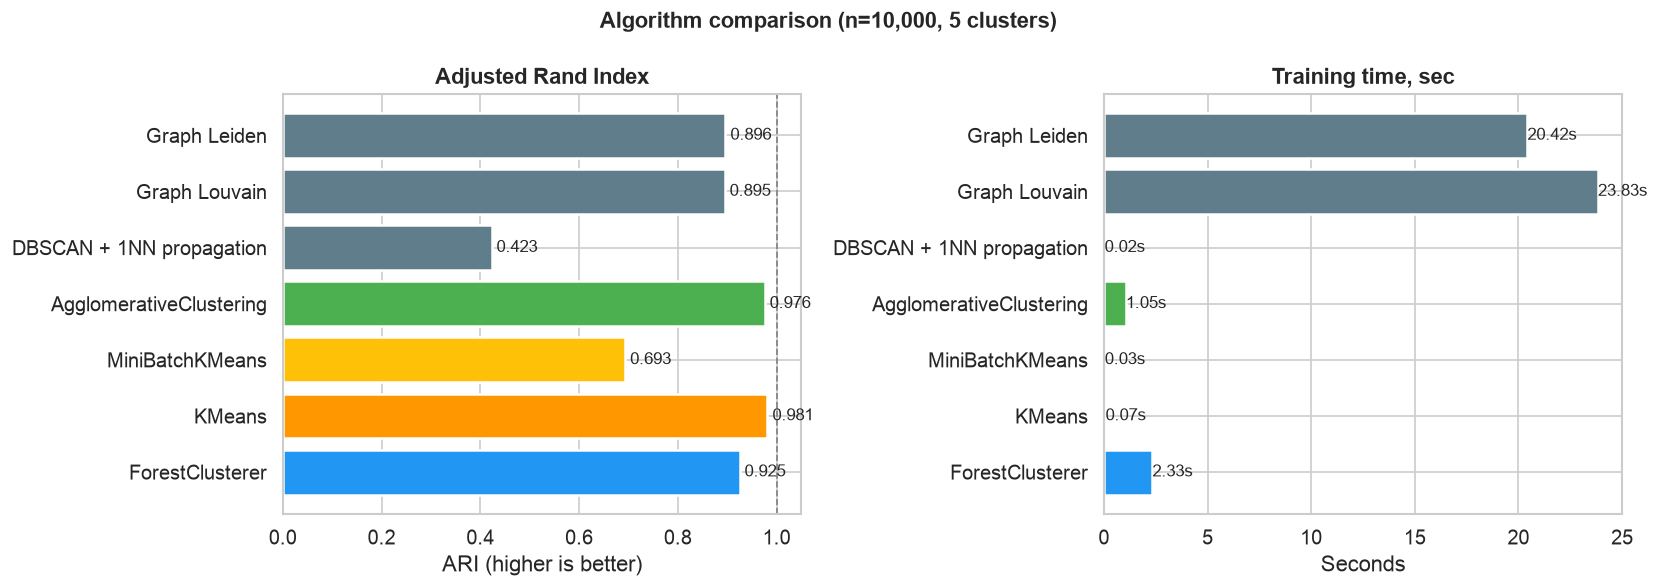

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
algo_names = list(results_clean.keys())
aris = [adjusted_rand_score(y_clean, results_clean[n]['labels']) for n in algo_names]
times = [results_clean[n]['time'] for n in algo_names]
colors = [ALGO_COLOR.get(n, '#607D8B') for n in algo_names]
# ARI
ax = axes[0]
bars = ax.barh(algo_names, aris, color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, aris):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=10)
ax.set_title('Adjusted Rand Index', fontweight='bold', fontsize=13)
ax.set_xlabel('ARI (higher is better)')
ax.axvline(1.0, color='gray', ls='--', lw=1)
# Time
ax = axes[1]
bars = ax.barh(algo_names, times, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, times):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}s',
            va='center', fontsize=10)
ax.set_title('Training time, sec', fontweight='bold', fontsize=13)
ax.set_xlabel('Seconds')
plt.suptitle(f'Algorithm comparison (n={N_COMPARE:,}, {N_CLUSTERS} clusters)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Outlier robustness

We append 1,000 uniform outliers (10% of the clean sample) to the **same 10,000 core observations**, refit each fixed-`K` method, and evaluate only the unchanged core rows. Generating a second dataset with the same seed would not be a valid before/after comparison because changing the requested core size also changes the random sample.

We report both ARI against the known classes and partition-stability ARI between clean and contaminated fits. Quantile cuts and Hamming distance bound the influence of extreme magnitudes, but they do not guarantee robustness: empirical quantiles, selected features, and downstream centroids may all change. One contamination draw is a stress test, not a statistical guarantee.

In [17]:
clean_mask = y_dirty != -1
assert clean_mask.sum() == len(df_clean)
assert df_dirty.loc[clean_mask].reset_index(drop=True).equals(df_clean.reset_index(drop=True))
X_prep_dirty = prep.transform(df_dirty)
# ForestClusterer + KMeans: use the same configuration as on clean data
t0 = time.perf_counter()
fc_d = ForestClusterer(
    n_iterations=250, n_bins=3, quantile_cuts=True,
    n_clusters=N_CLUSTERS,
    corr_threshold=0.9, corr_sample_size=5_000, random_state=42,
)
lbl_fc_d = fc_d.fit_predict(df_dirty)
t_fc_d = time.perf_counter()-t0
# KMeans: must assign ALL points to N_CLUSTERS clusters
t0 = time.perf_counter()
lbl_km_d = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42).fit_predict(X_prep_dirty)
t_km_d = time.perf_counter()-t0
# Agglomerative: same as KMeans — fixed n_clusters
t0 = time.perf_counter()
lbl_agg_d = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward').fit_predict(X_prep_dirty)
t_agg_d = time.perf_counter()-t0
print("All compared methods assign every point; robustness is evaluated on known core observations.")


All compared methods assign every point; robustness is evaluated on known core observations.


In [18]:
rob_rows = []
for name, lbl_d, lbl_c in [
    ('ForestClusterer', lbl_fc_d, fc_labels),
    ('KMeans', lbl_km_d, results_clean['KMeans']['labels']),
    ('AgglomerativeClustering', lbl_agg_d, results_clean['AgglomerativeClustering']['labels']),
]:
    lbl_d_core = lbl_d[clean_mask]
    ari_c = adjusted_rand_score(y_clean, lbl_c)
    ari_d = adjusted_rand_score(y_clean, lbl_d_core)
    rob_rows.append({
        'Algorithm': name,
        'ARI (clean)': round(ari_c, 3),
        'ARI (dirty, core obs)': round(ari_d, 3),
        'Partition stability ARI': round(adjusted_rand_score(lbl_c, lbl_d_core), 3),
    })
rob_df = pd.DataFrame(rob_rows).set_index('Algorithm')
rob_df['Δ ARI'] = rob_df['ARI (dirty, core obs)'] - rob_df['ARI (clean)']
rob_df


,ARI (clean),"ARI (dirty, core obs)",Partition stability ARI,Δ ARI
Algorithm,,,,
ForestClusterer,0.925,0.927,0.944,0.002
KMeans,0.981,0.608,0.610,-0.373
AgglomerativeClustering,0.976,0.613,0.615,-0.363


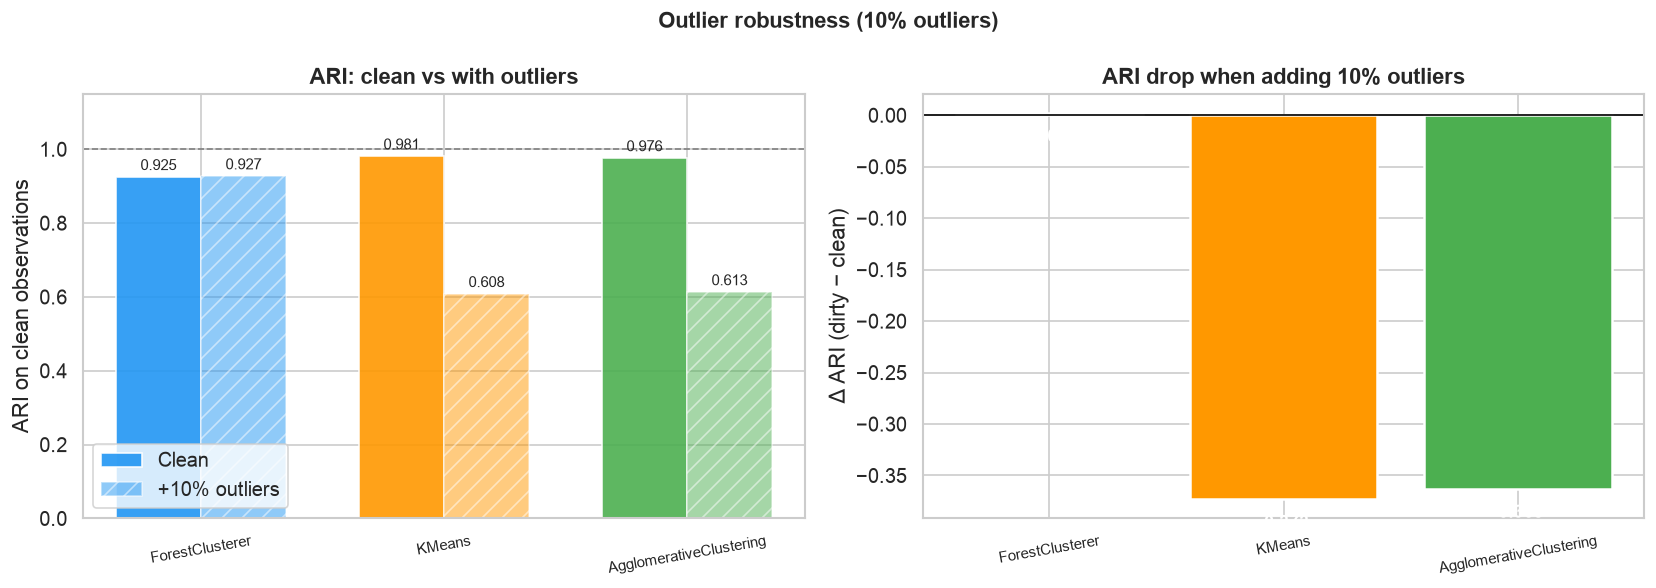

Smallest ARI degradation in this run: ForestClusterer (+0.002).
This experiment measures contamination robustness; these estimators do not detect outliers.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
algos_rob = ['ForestClusterer', 'KMeans', 'AgglomerativeClustering']
x = np.arange(len(algos_rob))
w = 0.35
aris_c = [rob_df.loc[n, 'ARI (clean)'] for n in algos_rob]
aris_d = [rob_df.loc[n, 'ARI (dirty, core obs)'] for n in algos_rob]
colors_bar = ['#2196F3', '#FF9800', '#4CAF50']
ax = axes[0]
b1 = ax.bar(x - w/2, aris_c, w, label='Clean', color=colors_bar, edgecolor='white', alpha=0.9)
b2 = ax.bar(x + w/2, aris_d, w, label='+10% outliers', color=colors_bar, edgecolor='white', alpha=0.5, hatch='//')
for bar, val in [(b, v) for bars, vals in [(b1, aris_c), (b2, aris_d)] for b, v in zip(bars, vals)]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(algos_rob, fontsize=9, rotation=10)
ax.set_ylim(0, 1.15); ax.set_ylabel('ARI on clean observations'); ax.set_title('ARI: clean vs with outliers', fontweight='bold')
ax.legend(); ax.axhline(1.0, color='gray', ls='--', lw=1)
# Δ ARI
ax = axes[1]
deltas = [d - c for c, d in zip(aris_c, aris_d)]
bars = ax.bar(algos_rob, deltas, color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, deltas):
    ax.text(bar.get_x()+bar.get_width()/2, val - 0.015, f'{val:+.3f}',
            ha='center', va='top', fontsize=11, fontweight='bold', color='white')
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('Δ ARI (dirty − clean)')
ax.set_title('ARI drop when adding 10% outliers', fontweight='bold')
ax.set_xticklabels(algos_rob, fontsize=9, rotation=10)
plt.suptitle('Outlier robustness (10% outliers)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
most_robust = rob_df['Δ ARI'].idxmax()
print(f"Smallest ARI degradation in this run: {most_robust} ({rob_df.loc[most_robust, 'Δ ARI']:+.3f}).")
print("This experiment measures contamination robustness; these estimators do not detect outliers.")


## 7. Online / incremental mode (`partial_fit`)

We fit on the first 5,000 rows and ingest 2,000 more in four batches. The drift report demonstrates state and diagnostics exposed by the API. It does not establish that incremental fitting matches a batch refit; that would require comparing embeddings/partitions on the same stream under repeated drift scenarios.

In [20]:
df_stream, y_stream = make_mixed_dataset(7_000, n_clusters=5, seed=99)
X_first = df_stream.iloc[:5_000]
X_new = df_stream.iloc[5_000:]
fc_online = ForestClusterer(
    n_iterations=200,
    partial_fit_strategy='drift',
    partial_fit_drift_threshold=0.3,
    partial_fit_rebuild_threshold=0.3,
    random_state=42,
)
# Initial fit
fc_online.fit(X_first)
print(f"Initial fit: n={len(X_first)}, embedding shape={fc_online.embedding_.shape}")
# Incremental updates
for batch in np.array_split(X_new, 4):
    fc_online.partial_fit(batch)
    print(f"  partial_fit: n={len(batch)}, total embedding={fc_online.embedding_.shape}")
# Drift report
report = fc_online.get_drift_report()
print(f"Drift report keys: {list(report.keys())[:5]}...")


Initial fit: n=5000, embedding shape=(5000, 200)


  partial_fit: n=500, total embedding=(5500, 200)


  partial_fit: n=500, total embedding=(6000, 200)


  partial_fit: n=500, total embedding=(6500, 200)


  partial_fit: n=500, total embedding=(7000, 200)
Drift report keys: [0, 1, 2, 7, 8]...


## 8. Empirical runtime scaling

This is a small local benchmark, not a complexity proof. We report the median of three end-to-end fits for each sample size. The sklearn timing includes fitting the preprocessor and KMeans; the ForestClustering timing includes embedding and its default downstream clusterer. Correlation detection is disabled in this section to isolate the main embedding path.

A log-log slope is shown only as a compact description of the measured range. It should not be extrapolated: implementation thresholds, cache effects, dimensionality, and clustering backends can change the curve.

In [21]:
# Embedding time vs n_samples
N_RANGE = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000]
N_ITER_SCALE = 200
TIME_REPEATS = 3
times_fc, times_km = [], []
for n in N_RANGE:
    df_n, _ = make_mixed_dataset(n, n_clusters=5, seed=0)
    fc_runs, km_runs = [], []
    for _ in range(TIME_REPEATS):
        fc_scale = ForestClusterer(
            n_iterations=N_ITER_SCALE, n_bins=3,
            corr_threshold=None, random_state=0,
        )
        t0 = time.perf_counter()
        fc_scale.fit(df_n)
        fc_runs.append(time.perf_counter() - t0)

        prep_n = make_preprocessor()
        t0 = time.perf_counter()
        X_n = prep_n.fit_transform(df_n)
        KMeans(n_clusters=5, n_init=5, random_state=0).fit(X_n)
        km_runs.append(time.perf_counter() - t0)
    times_fc.append(float(np.median(fc_runs)))
    times_km.append(float(np.median(km_runs)))
    print(f"n={n:>7,} ForestClusterer={times_fc[-1]:.2f}s KMeans={times_km[-1]:.2f}s")


n=  1,000 ForestClusterer=0.17s KMeans=0.01s


n=  5,000 ForestClusterer=0.41s KMeans=0.03s


n= 10,000 ForestClusterer=1.04s KMeans=0.02s


n= 25,000 ForestClusterer=0.43s KMeans=0.04s


n= 50,000 ForestClusterer=0.71s KMeans=0.07s


n=100,000 ForestClusterer=1.46s KMeans=0.11s


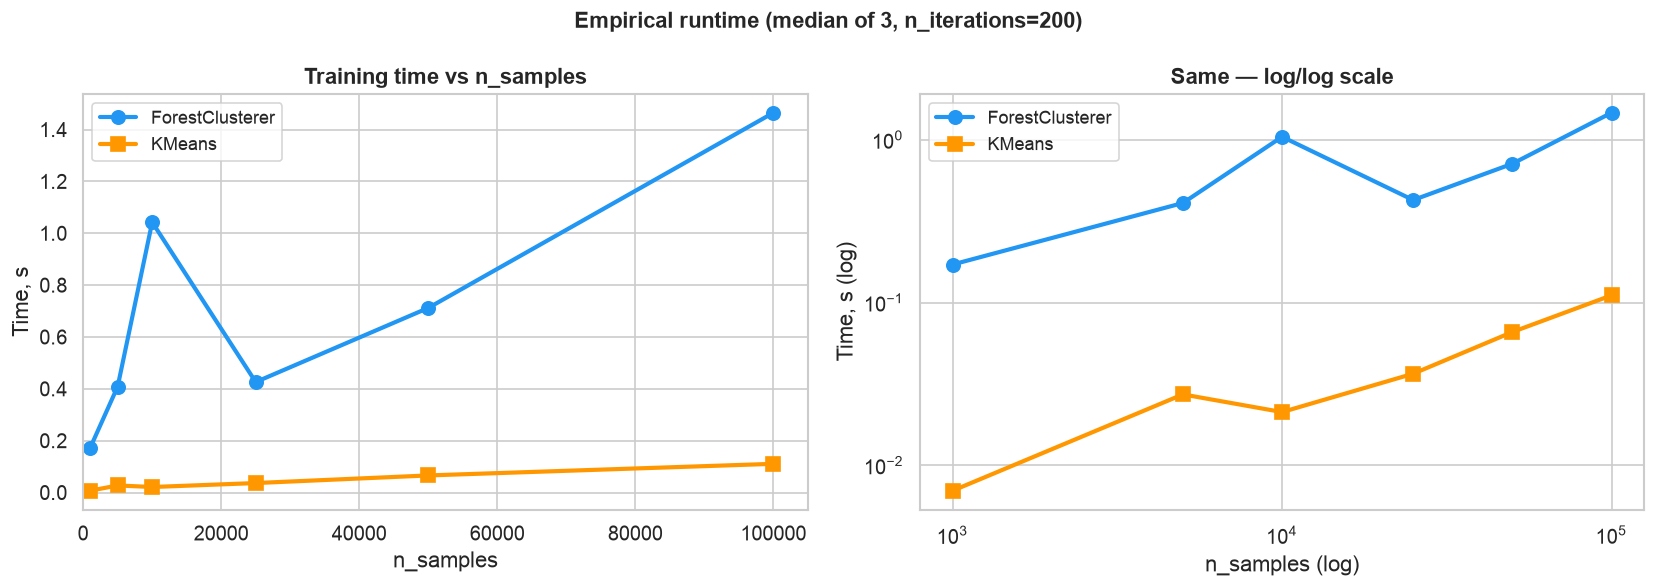

Measured log-log slope: ForestClusterer=0.38, sklearn pipeline=0.56
These exponents summarize only the points above; they are not asymptotic guarantees.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(N_RANGE, times_fc, 'o-', color='#2196F3', lw=2.5, ms=8, label='ForestClusterer')
ax.plot(N_RANGE, times_km, 's-', color='#FF9800', lw=2.5, ms=8, label='KMeans')
ax.set_xlabel('n_samples')
ax.set_ylabel('Time, s')
ax.set_title('Training time vs n_samples', fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(0, N_RANGE[-1] * 1.05)
ax = axes[1]
ax.plot(N_RANGE, times_fc, 'o-', color='#2196F3', lw=2.5, ms=8, label='ForestClusterer')
ax.plot(N_RANGE, times_km, 's-', color='#FF9800', lw=2.5, ms=8, label='KMeans')
ax.set_yscale('log'); ax.set_xscale('log')
ax.set_xlabel('n_samples (log)')
ax.set_ylabel('Time, s (log)')
ax.set_title('Same — log/log scale', fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
plt.suptitle(f'Empirical runtime (median of {TIME_REPEATS}, n_iterations={N_ITER_SCALE})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
log_n = np.log(N_RANGE)
fc_slope = np.polyfit(log_n, np.log(times_fc), 1)[0]
km_slope = np.polyfit(log_n, np.log(times_km), 1)[0]
print(f'Measured log-log slope: ForestClusterer={fc_slope:.2f}, sklearn pipeline={km_slope:.2f}')
print('These exponents summarize only the points above; they are not asymptotic guarantees.')


## Summary

What this example supports:

- ForestClustering can consume the mixed dataframe directly and expose an inspectable embedding and feature weights.
- On this generator, fixed-`K` ForestClustering reaches ARI `0.925` and common-space silhouette `0.236`; ordinary KMeans (`0.981`, `0.247`) and Ward (`0.976`, `0.245`) are stronger. The baseline table, not the library name, determines that conclusion.
- With exploratory `k=100, resolution=0.1`, graph clustering returns six communities and ARI about `0.895`. That is credible but worse than all three fixed-`K` results; it should be described as a trade for not specifying `K`, not as an improvement. The LSH graph is connected in this run.
- In the explicit 10% contamination scenario, ForestClustering retains ARI `0.927` and partition stability `0.944`, whereas KMeans/Ward fall to about `0.61`. This is strong evidence for this constructed mechanism, but another outlier distribution or seed may rank methods differently.
- `partial_fit` is an engineering capability; the short streaming example does not establish statistical equivalence to a full refit.
- Runtime curves are local empirical measurements. The drop between 10k and 25k is an implementation-path change: the default backend uses dense one-hot features through 12k rows and sparse features above that threshold. The non-monotone curve does not prove linear complexity or a general speed advantage.

Use this notebook as a template for controlled evaluation: define truth where possible, compare in a shared metric space, time complete pipelines, preserve rows in stress tests, and report failure modes alongside strengths.